In [1]:
import pickle

#Unpickling the data
with open('/content/images.p','rb') as f:
  images = pickle.load(f)

with open('/content/labels.p','rb') as f:
  labels = pickle.load(f)

In [2]:
print(images.shape)
print(labels.shape)

(253, 100, 100)
(253,)


In [3]:
set(labels)

{'Dhananjay', 'Hanma', 'Vicky'}

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

labels = le.fit_transform(labels)

In [5]:
set(labels)

{0, 1, 2}

In [6]:
import numpy as np

In [7]:
p = len(set(labels))
print("Number of Persons : ",p)

a = le.inverse_transform(np.arange(p))
for i in range(len(a)):
  print(i,'-->',a[i])

Number of Persons :  3
0 --> Dhananjay
1 --> Hanma
2 --> Vicky


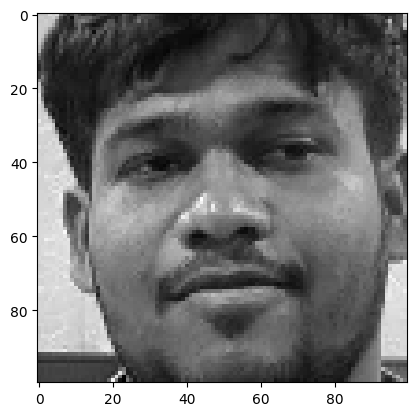

In [8]:
import matplotlib.pyplot as plt

plt.imshow(images[200],cmap='gray')
plt.show()

In [9]:
import cv2

In [10]:
def preprocessing(img):
  img = cv2.equalizeHist(img)
  img = img.reshape(100,100,1)
  img = img/255
  return img

In [18]:
images = np.array(list(map(preprocessing,images)))
print('Shape of Image : ',images.shape)

Shape of Image :  (253, 100, 100, 1)


In [19]:
from keras.utils import to_categorical
labels = to_categorical(labels)

In [21]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten